# RL 학습 결과 시각화


In [6]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# History 파일 경로
# history_path = "/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/src/rl/outputs/runs/20251012-171846/history.json"
# history_path = "/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/src/rl/outputs/runs/20251015-231700/history.json"
# history_path = "/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/src/rl/outputs/runs/20251018-213951/history.json"
# history_path = "/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/temp/history.json"
history_path = "/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/temp/best_history.json"

# 데이터 로드
with open(history_path, 'r') as f:
    history = json.load(f)

# 데이터 추출
iterations = [h['iteration'] + 1 for h in history]  # 1부터 시작
mean_rewards = [h['mean_reward'] for h in history]
std_rewards = [h['std_reward'] for h in history]
mean_values = [h['mean_value'] for h in history]
losses = [h['loss'] for h in history]
policy_losses = [h['policy_loss'] for h in history]
value_losses = [h['value_loss'] for h in history]
entropies = [h['mean_entropy'] for h in history]
approx_kls = [h['approx_kl'] for h in history]
clipfracs = [h['clipfrac'] for h in history]
num_episodes = [h['num_episodes'] for h in history]
iter_times = [h['iter_time'] for h in history]

print(f"총 {len(history)} iterations 학습 완료")
print(f"초기 보상: {mean_rewards[0]:.2f}")
print(f"최종 보상: {mean_rewards[-1]:.2f}")
print(f"최대 보상: {max(mean_rewards):.2f}")
print(f"총 소요 시간: {sum(iter_times):.1f}s ({sum(iter_times)/60:.1f}분)")


총 10 iterations 학습 완료
초기 보상: 0.09
최종 보상: 0.13
최대 보상: 0.13
총 소요 시간: 2783.3s (46.4분)


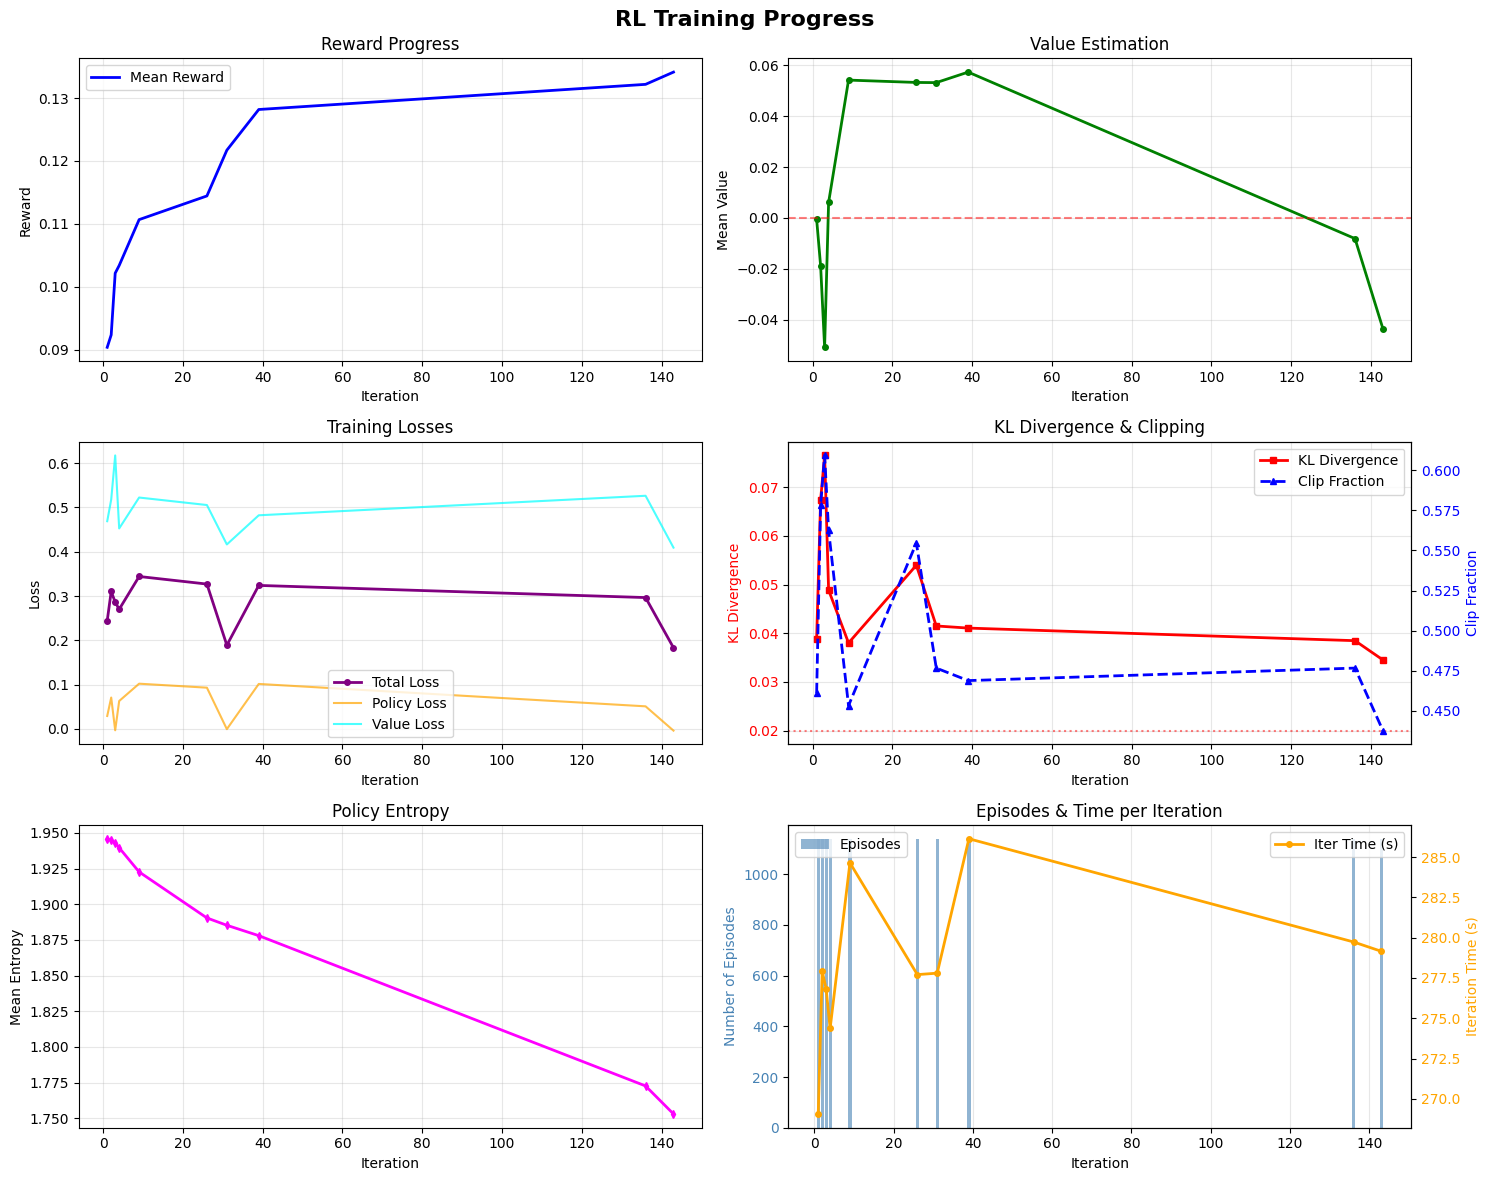

In [13]:
# 전체 학습 곡선 시각화
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('RL Training Progress', fontsize=16, fontweight='bold')

# 1. Reward (mean ± std)
ax = axes[0, 0]
ax.plot(iterations, mean_rewards, 'b-', linewidth=2, label='Mean Reward')
# ax.fill_between(iterations, 
#                  np.array(mean_rewards) - np.array(std_rewards), 
#                  np.array(mean_rewards) + np.array(std_rewards), 
#                  alpha=0.3, color='blue', label='±1 Std')
ax.set_xlabel('Iteration')
ax.set_ylabel('Reward')
ax.set_title('Reward Progress')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Value Estimation
ax = axes[0, 1]
ax.plot(iterations, mean_values, 'g-', linewidth=2, marker='o', markersize=4)
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean Value')
ax.set_title('Value Estimation')
ax.grid(True, alpha=0.3)

# 3. Losses
ax = axes[1, 0]
ax.plot(iterations, losses, 'purple', linewidth=2, label='Total Loss', marker='o', markersize=4)
ax.plot(iterations, policy_losses, 'orange', linewidth=1.5, label='Policy Loss', alpha=0.7)
ax.plot(iterations, value_losses, 'cyan', linewidth=1.5, label='Value Loss', alpha=0.7)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Training Losses')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. KL Divergence & Clip Fraction
ax = axes[1, 1]
ax2 = ax.twinx()
line1 = ax.plot(iterations, approx_kls, 'r-', linewidth=2, label='KL Divergence', marker='s', markersize=4)
line2 = ax2.plot(iterations, clipfracs, 'b--', linewidth=2, label='Clip Fraction', marker='^', markersize=4)
ax.axhline(y=0.02, color='r', linestyle=':', alpha=0.5, label='Target KL')
ax.set_xlabel('Iteration')
ax.set_ylabel('KL Divergence', color='r')
ax2.set_ylabel('Clip Fraction', color='b')
ax.tick_params(axis='y', labelcolor='r')
ax2.tick_params(axis='y', labelcolor='b')
ax.set_title('KL Divergence & Clipping')
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper right')
ax.grid(True, alpha=0.3)

# 5. Entropy
ax = axes[2, 0]
ax.plot(iterations, entropies, 'magenta', linewidth=2, marker='d', markersize=4)
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean Entropy')
ax.set_title('Policy Entropy')
ax.grid(True, alpha=0.3)

# 6. Episodes & Time
ax = axes[2, 1]
ax2 = ax.twinx()
line1 = ax.bar(iterations, num_episodes, alpha=0.6, color='steelblue', label='Episodes')
line2 = ax2.plot(iterations, iter_times, 'orange', linewidth=2, marker='o', markersize=4, label='Iter Time (s)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Number of Episodes', color='steelblue')
ax2.set_ylabel('Iteration Time (s)', color='orange')
ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='orange')
ax.set_title('Episodes & Time per Iteration')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


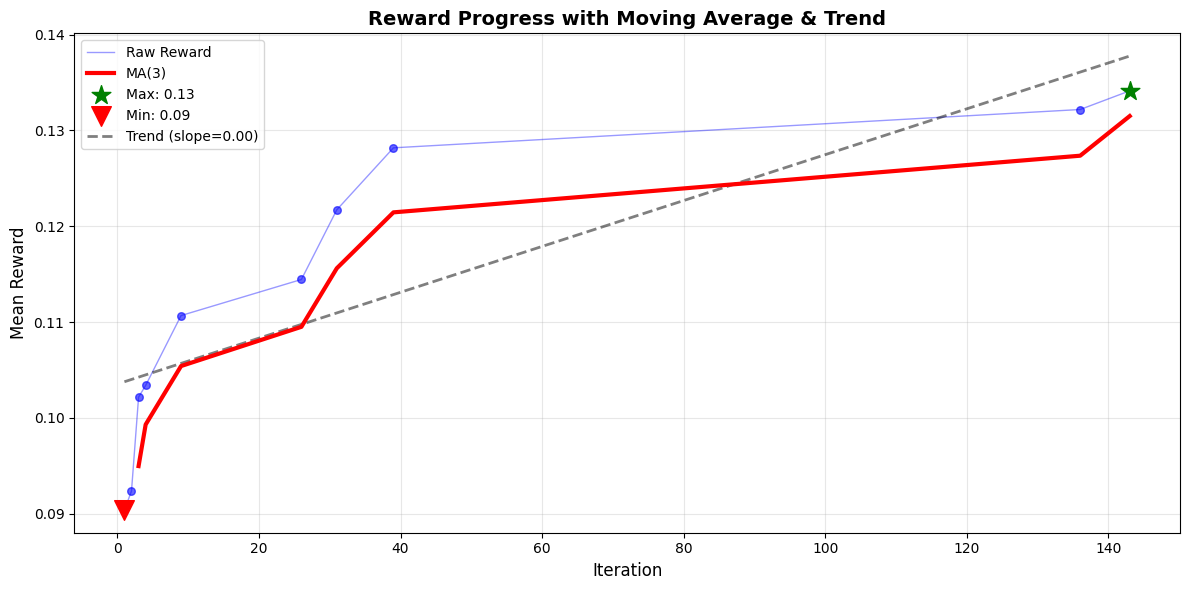


📊 보상 개선:
  초기 → 최종: 0.09 → 0.13
  절대 개선: +0.04
  상대 개선: +48.40%
  최대 도달: 0.13 (Iter 143)
  최소 도달: 0.09 (Iter 1)


In [14]:
# 보상 상세 분석 (Moving Average 포함)
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Moving average 계산 (window=3)
window = 3
if len(mean_rewards) >= window:
    ma_rewards = np.convolve(mean_rewards, np.ones(window)/window, mode='valid')
    ma_iterations = iterations[window-1:]
else:
    ma_rewards = mean_rewards
    ma_iterations = iterations

# 원본 데이터
ax.plot(iterations, mean_rewards, 'b-', alpha=0.4, linewidth=1, label='Raw Reward')
ax.scatter(iterations, mean_rewards, c='blue', s=30, alpha=0.6, zorder=5)

# Moving average
if len(mean_rewards) >= window:
    ax.plot(ma_iterations, ma_rewards, 'r-', linewidth=3, label=f'MA({window})', zorder=10)

# # 에러바 (std)
# ax.errorbar(iterations, mean_rewards, yerr=std_rewards, fmt='none', 
#             ecolor='gray', alpha=0.3, capsize=3, label='±1 Std')

# 최대/최소 표시
max_idx = np.argmax(mean_rewards)
min_idx = np.argmin(mean_rewards)
ax.scatter(iterations[max_idx], mean_rewards[max_idx], 
          c='green', s=200, marker='*', zorder=15, label=f'Max: {mean_rewards[max_idx]:.2f}')
ax.scatter(iterations[min_idx], mean_rewards[min_idx], 
          c='red', s=200, marker='v', zorder=15, label=f'Min: {mean_rewards[min_idx]:.2f}')

# 트렌드 라인 (선형 회귀)
z = np.polyfit(iterations, mean_rewards, 1)
p = np.poly1d(z)
ax.plot(iterations, p(iterations), "k--", alpha=0.5, linewidth=2, 
        label=f'Trend (slope={z[0]:.2f})')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Mean Reward', fontsize=12)
ax.set_title('Reward Progress with Moving Average & Trend', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 보상 개선 통계
improvement = mean_rewards[-1] - mean_rewards[0]
improvement_pct = (improvement / abs(mean_rewards[0])) * 100
print(f"\n📊 보상 개선:")
print(f"  초기 → 최종: {mean_rewards[0]:.2f} → {mean_rewards[-1]:.2f}")
print(f"  절대 개선: {improvement:+.2f}")
print(f"  상대 개선: {improvement_pct:+.2f}%")
print(f"  최대 도달: {max(mean_rewards):.2f} (Iter {iterations[max_idx]})")
print(f"  최소 도달: {min(mean_rewards):.2f} (Iter {iterations[min_idx]})")



🎯 KL Divergence 분석:
  평균: 0.0479
  범위: [0.0345, 0.0765]
  위반 횟수 (>0.03): 10/10

✂️  Clip Fraction 분석:
  평균: 0.5078
  범위: [0.4375, 0.6094]
  높은 clipping (>0.5): 4/10

🌡️  Entropy 분석:
  초기: 1.9459
  최종: 1.7529
  감소율: 9.92%
  (높은 entropy = 탐색적, 낮은 entropy = 수렴)


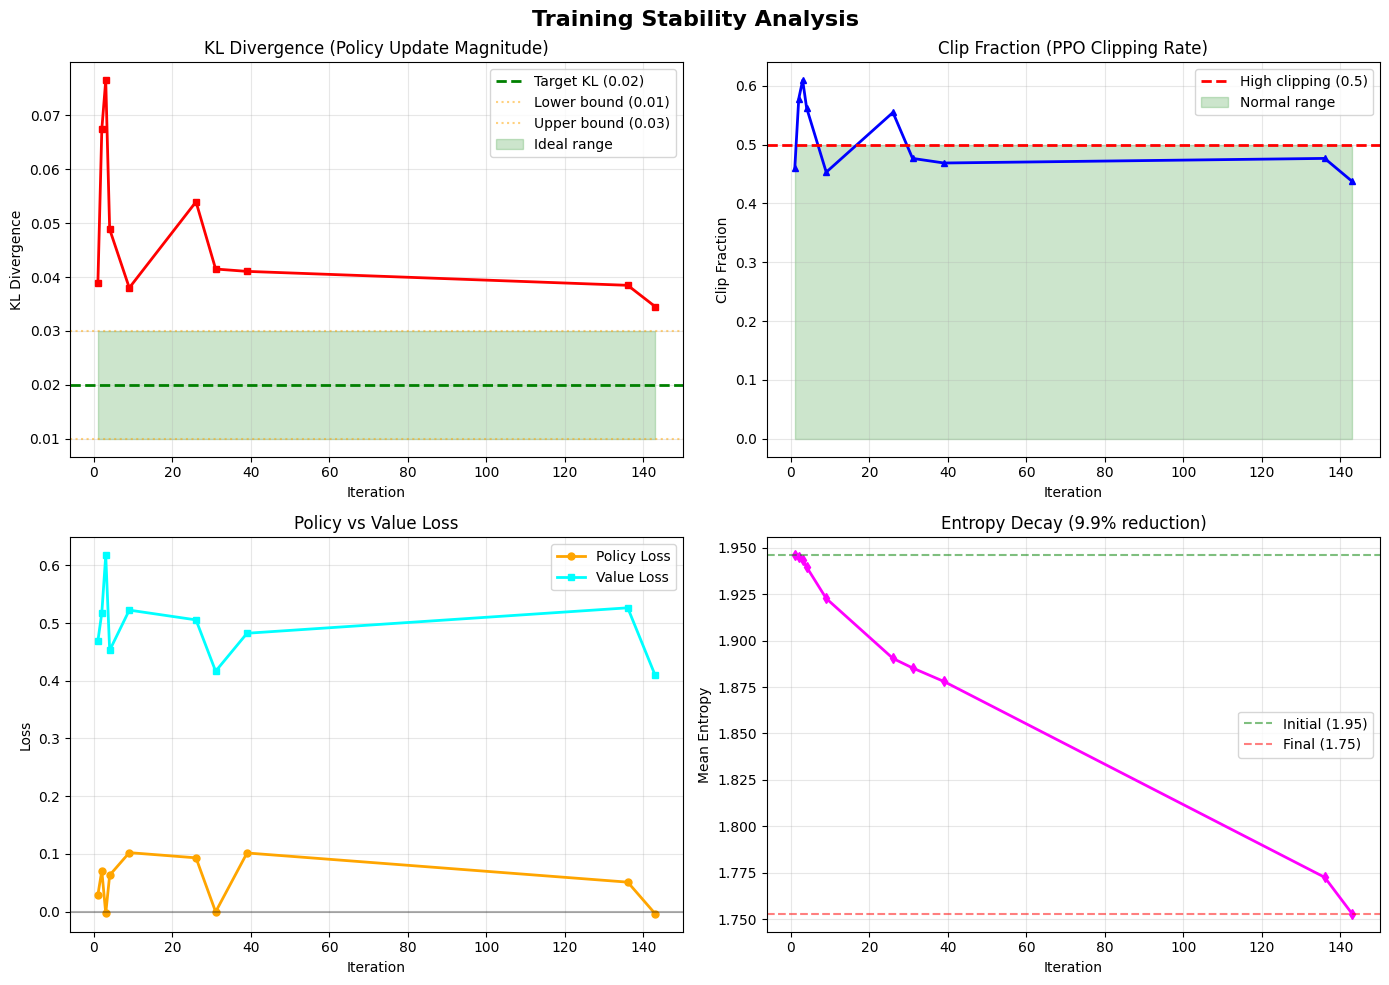

In [9]:
# 학습 안정성 분석
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Stability Analysis', fontsize=16, fontweight='bold')

# 1. KL Divergence 상세
ax = axes[0, 0]
ax.plot(iterations, approx_kls, 'r-', linewidth=2, marker='s', markersize=5)
ax.axhline(y=0.02, color='green', linestyle='--', linewidth=2, label='Target KL (0.02)')
ax.axhline(y=0.01, color='orange', linestyle=':', alpha=0.5, label='Lower bound (0.01)')
ax.axhline(y=0.03, color='orange', linestyle=':', alpha=0.5, label='Upper bound (0.03)')
ax.fill_between(iterations, 0.01, 0.03, alpha=0.2, color='green', label='Ideal range')
ax.set_xlabel('Iteration')
ax.set_ylabel('KL Divergence')
ax.set_title('KL Divergence (Policy Update Magnitude)')
ax.legend()
ax.grid(True, alpha=0.3)

# KL 통계
kl_violations = sum(1 for kl in approx_kls if kl > 0.03)
kl_mean = np.mean(approx_kls)
print(f"\n🎯 KL Divergence 분석:")
print(f"  평균: {kl_mean:.4f}")
print(f"  범위: [{min(approx_kls):.4f}, {max(approx_kls):.4f}]")
print(f"  위반 횟수 (>0.03): {kl_violations}/{len(approx_kls)}")

# 2. Clip Fraction 상세
ax = axes[0, 1]
ax.plot(iterations, clipfracs, 'b-', linewidth=2, marker='^', markersize=5)
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='High clipping (0.5)')
ax.fill_between(iterations, 0, 0.5, alpha=0.2, color='green', label='Normal range')
ax.set_xlabel('Iteration')
ax.set_ylabel('Clip Fraction')
ax.set_title('Clip Fraction (PPO Clipping Rate)')
ax.legend()
ax.grid(True, alpha=0.3)

# Clip 통계
clip_mean = np.mean(clipfracs)
clip_high = sum(1 for cf in clipfracs if cf > 0.5)
print(f"\n✂️  Clip Fraction 분석:")
print(f"  평균: {clip_mean:.4f}")
print(f"  범위: [{min(clipfracs):.4f}, {max(clipfracs):.4f}]")
print(f"  높은 clipping (>0.5): {clip_high}/{len(clipfracs)}")

# 3. Loss 분해
ax = axes[1, 0]
ax.plot(iterations, policy_losses, 'orange', linewidth=2, marker='o', label='Policy Loss', markersize=5)
ax.plot(iterations, value_losses, 'cyan', linewidth=2, marker='s', label='Value Loss', markersize=5)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Policy vs Value Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Entropy 감소
ax = axes[1, 1]
ax.plot(iterations, entropies, 'magenta', linewidth=2, marker='d', markersize=5)
entropy_start = entropies[0]
entropy_end = entropies[-1]
entropy_decay = (entropy_start - entropy_end) / entropy_start * 100
ax.axhline(y=entropy_start, color='green', linestyle='--', alpha=0.5, label=f'Initial ({entropy_start:.2f})')
ax.axhline(y=entropy_end, color='red', linestyle='--', alpha=0.5, label=f'Final ({entropy_end:.2f})')
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean Entropy')
ax.set_title(f'Entropy Decay ({entropy_decay:.1f}% reduction)')
ax.legend()
ax.grid(True, alpha=0.3)

print(f"\n🌡️  Entropy 분석:")
print(f"  초기: {entropy_start:.4f}")
print(f"  최종: {entropy_end:.4f}")
print(f"  감소율: {entropy_decay:.2f}%")
print(f"  (높은 entropy = 탐색적, 낮은 entropy = 수렴)")

plt.tight_layout()
plt.show()


In [10]:
# 전체 학습 요약 테이블
import pandas as pd

summary_data = {
    'Iteration': iterations,
    'Mean Reward': mean_rewards,
    'Std Reward': std_rewards,
    'Mean Value': mean_values,
    'Total Loss': losses,
    'Policy Loss': policy_losses,
    'Value Loss': value_losses,
    'Entropy': entropies,
    'KL Div': approx_kls,
    'Clip Frac': clipfracs,
    'Episodes': num_episodes,
    'Time (s)': iter_times
}

df = pd.DataFrame(summary_data)

print("\n" + "="*100)
print("📋 학습 요약 테이블")
print("="*100)
print(df.to_string(index=False))

print("\n" + "="*100)
print("📊 전체 통계")
print("="*100)
print(df.describe().round(4).to_string())

# 최고/최저 성능 iteration
print("\n" + "="*100)
print("🏆 주요 이정표")
print("="*100)
best_reward_idx = df['Mean Reward'].idxmax()
worst_reward_idx = df['Mean Reward'].idxmin()
print(f"\n최고 성능 (Iteration {df.loc[best_reward_idx, 'Iteration']}):")
print(df.loc[best_reward_idx].to_string())
print(f"\n최저 성능 (Iteration {df.loc[worst_reward_idx, 'Iteration']}):")
print(df.loc[worst_reward_idx].to_string())



📋 학습 요약 테이블
 Iteration  Mean Reward  Std Reward  Mean Value  Total Loss  Policy Loss  Value Loss  Entropy   KL Div  Clip Frac  Episodes   Time (s)
         1     0.090386    0.453665   -0.000525    0.244379     0.029373    0.468919 1.945909 0.038857   0.460938      1137 269.059346
         2     0.092366    0.467326   -0.018887    0.310368     0.070916    0.517783 1.944817 0.067424   0.578125      1137 277.920994
         3     0.102164    0.460729   -0.050823    0.286363    -0.002918    0.617377 1.943101 0.076504   0.609375      1137 276.816086
         4     0.103388    0.502098    0.006128    0.270090     0.063153    0.452603 1.939584 0.048859   0.562500      1137 274.367824
         9     0.110679    0.476647    0.054188    0.344171     0.102233    0.522352 1.922653 0.038000   0.453125      1137 284.642653
        26     0.114444    0.495934    0.053263    0.327074     0.093235    0.505429 1.890386 0.053961   0.554688      1137 277.707235
        31     0.121717    0.476369    0.0